In [1]:
import spatialdata as sd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad
import pandas as pd
import numpy as np
import decoupler as dc

/deepdata/share/conda-envs/envs/xenium/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/deepdata/share/conda-envs/envs/xenium/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/deepdata/share/conda-envs/envs/xenium/lib/python3.12/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Vers

In [2]:
normed_data = ad.read_h5ad('results_full_pdac/processed_data.h5ad')

In [3]:
normed_data

AnnData object with n_obs × n_vars = 992465 × 5091
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res0p05', 'leiden_res0p1', 'leiden_res0p2', 'leiden_res0p3', 'leiden_res0p5', 'leiden_res1p0', 'leiden_res2p0', 'leiden_res3p0', 'cell_type_res0p05', 'cell_type_res0p1', 'cell_type_res0p2', 'cell_type_res0p3', 'cell_type_res0p5', 'cell_typ

In [4]:
normed_data.obs['HIV_POS'] = normed_data.obs['sample'].str.endswith('Pos')

In [5]:
from scipy.stats import chi2_contingency

In [6]:
obs = pd.crosstab(normed_data.obs['leiden_res0p5'], normed_data.obs['HIV_POS'])
chi2_res = chi2_contingency(obs)
print(f'p={chi2_res.pvalue}')

p=0.0


Text(0, 0.5, 'Cells')

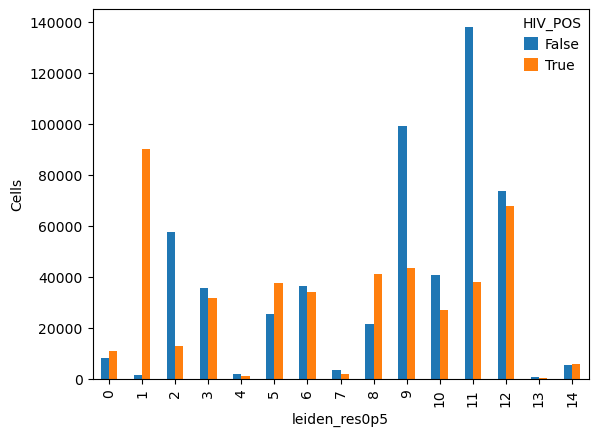

In [7]:
ax = obs.plot(kind = 'bar')
ax.set_ylabel('Cells')

In [8]:
obs-chi2_res.expected_freq

HIV_POS,False,True
leiden_res0p5,,
0,-2406.825600,2406.825600
1,-49222.486119,49222.486119
2,18623.235402,-18623.235402
3,-1699.675210,1699.675210
4,328.367506,-328.367506
5,-9277.824616,9277.824616
6,-2520.355553,2520.355553
7,526.040736,-526.040736
8,-13073.766521,13073.766521


In [9]:
dc.op.show_resources().query("license == 'academic'")

,name,license
2,Baccin2019,academic
3,CORUM_Funcat,academic
4,CORUM_GO,academic
8,CancerDrugsDB,academic
9,CancerGeneCensus,academic
10,CancerSEA,academic
19,Cellinker,academic
20,Cellinker_complex,academic
24,DisGeNet,academic
34,HPMR,academic


In [ ]:
def get_panglao():
    "Best practices per: https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_sc.html#panglaodb"
    
    markers = dc.op.resource("PanglaoDB", organism="human")
    markers = markers[markers["human"].astype(bool)
      & markers["canonical_marker"].astype(bool)
      & (markers["human_sensitivity"].astype(float) > 0.5)]
    markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]
    markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
    return markers[["source", "target"]]
    

resources = [('hallmark', dc.op.hallmark(organism="human")),
             ('collectri', dc.op.collectri(organism="human")),
            ('dorothea', dc.op.dorothea(organism="human")),
            ('progeny', dc.op.progeny(organism="human")),
             ('PanglaoDB', get_panglao())]

# pre-computer the ULM score for all resources and save them into new obsm_keys
for name, resource in resources:
    dc.mt.ulm(data=normed_data, net=resource, tmin=5)
    normed_data.obsm[f'score_ulm_{name}'] = normed_data.obsm['score_ulm']

In [12]:
from scipy.stats import ranksums, false_discovery_control

In [13]:
results = []
resolution = 'res0p5'


for name, resource in resources:
    print(name)
    layer = f'score_ulm_{name}_{resolution}'

    dc.mt.ulm(data=normed_data, net=resource, tmin=5)
    normed_data.obsm[layer] = normed_data.obsm['score_ulm']
    
    score_ulm = pd.DataFrame(normed_data.obsm[layer])
    
    for clust, cdf in normed_data.obs.groupby('leiden_'+resolution):
        cluster_ulm = score_ulm.loc[cdf.index]
        mask = cdf['HIV_POS']
        pos_ulm = cluster_ulm.loc[mask]
        neg_ulm = cluster_ulm.loc[~mask]
        delta = pos_ulm.mean(axis=0)-neg_ulm.mean(axis=0)
        stats, pvals = ranksums(pos_ulm, neg_ulm, alternative='two-sided', axis=0, nan_policy='omit', keepdims=False)
        for stat, pval, d, col in zip(stats.flatten(), pvals.flatten(), delta, pos_ulm.columns):
            results.append({'cluster': clust,
                            'name': name,
                            'target': col,
                            'stat': stat,
                            'pval': pval, 
                            'delta_mean': d})
    
    
    
res_df = pd.DataFrame(results)
res_df['pval_adj'] = false_discovery_control(res_df['pval'])
res_df  

hallmark


/tmp/ipykernel_22130/3197906854.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, cdf in normed_data.obs.groupby('leiden_'+resolution):


collectri


/tmp/ipykernel_22130/3197906854.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, cdf in normed_data.obs.groupby('leiden_'+resolution):


dorothea


...

progeny


/tmp/ipykernel_22130/3197906854.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, cdf in normed_data.obs.groupby('leiden_'+resolution):


PanglaoDB


/tmp/ipykernel_22130/3197906854.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, cdf in normed_data.obs.groupby('leiden_'+resolution):


,cluster,name,target,stat,pval,delta_mean,pval_adj
0,0,hallmark,ADIPOGENESIS,-23.601294,3.737945e-123,-0.369950,1.181856e-122
1,0,hallmark,ALLOGRAFT_REJECTION,-57.247032,0.000000e+00,-0.728565,0.000000e+00
2,0,hallmark,ANDROGEN_RESPONSE,-37.009136,8.164416e-300,-0.663817,4.428255e-299
3,0,hallmark,ANGIOGENESIS,-0.334826,7.377567e-01,-0.027363,7.559947e-01
4,0,hallmark,APICAL_JUNCTION,-17.546957,6.275291e-69,-0.279975,1.547250e-68
...,...,...,...,...,...,...,...
15415,14,PanglaoDB,Platelets,6.634375,3.258811e-11,0.154303,4.960109e-11
15416,14,PanglaoDB,Podocytes,10.100450,5.498938e-24,0.055931,9.927833e-24
15417,14,PanglaoDB,Proximal tubule cells,23.631537,1.827654e-123,0.048221,5.784571e-123
15418,14,PanglaoDB,Pulmonary alveolar type II cells,25.429400,1.193211e-142,0.110815,4.067945e-142


In [153]:
normed_data.obsm['score_ulm_hallmark_res0p5']

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
0,0.714971,0.211003,4.789652,2.880766,2.065135,-0.189158,4.560904,-1.273036,0.076052,-1.207510,...,2.103332,-0.746310,-0.022039,4.216913,0.364649,4.054280,0.714971,1.277672,0.988018,1.104580
1,3.564975,3.269165,3.864227,1.886048,-1.187914,-0.071562,3.015754,-0.623792,0.292902,-0.052919,...,3.639690,-0.868045,-0.866140,2.443483,-0.942615,-0.411605,-0.170701,1.362707,0.412839,-1.082254
2,1.964841,-0.383755,1.027903,0.129641,-0.520647,-1.341616,0.456436,-0.797009,1.859353,0.491807,...,1.266579,-1.161135,-0.174712,4.551536,-0.586217,2.007033,1.285952,0.526653,2.638402,-0.217643
3,0.598364,3.090083,1.482243,-0.761227,0.851764,1.556546,0.549416,-0.181284,-0.998199,-0.684328,...,0.899449,0.663118,-1.213265,-0.082546,-0.718022,1.447359,-0.079907,-0.117180,-0.955412,-1.640086
4,0.690436,3.781744,1.846522,2.342919,-0.260187,0.452317,2.209538,-0.306946,0.554636,2.748533,...,-0.778247,-0.068922,-1.165873,0.813158,1.503206,1.321994,2.344316,0.658843,-0.661042,-1.279163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74281-3,1.777327,0.807114,2.086949,1.205322,3.579496,2.712920,2.694602,0.451376,1.968538,1.914782,...,1.921490,1.389230,-0.905516,0.554942,0.175363,-0.723882,2.728403,-0.149493,-0.713086,-0.388248
74298-3,-1.178393,-0.490486,1.179116,3.476545,1.302760,3.218283,0.169554,-0.884896,2.791456,3.122270,...,-0.830137,-0.577903,-0.059910,5.313940,5.501099,0.369880,4.195163,0.671100,6.058391,1.283510
74313-3,0.786924,0.535197,2.819526,1.162755,1.100884,-0.600618,3.808194,-0.795980,-0.736490,0.465682,...,1.856040,1.342256,-0.895151,0.527175,-0.591972,-0.715596,2.028870,-0.162981,-0.704923,-1.209995
74319-3,-0.108244,-1.462686,1.663001,-0.555640,0.357982,-0.594182,-1.259106,-0.787450,-0.728598,-0.038711,...,-0.738722,-0.514268,2.442063,-0.748713,0.944259,-0.707927,-1.048613,-0.134799,-0.697369,0.457820


In [159]:
spatials = pd.DataFrame(normed_data.obsm['spatial'])
spatials

,0,1
0,393.175964,6214.786621
1,393.943909,6206.773438
2,392.817413,6221.879395
3,587.246155,6223.839355
4,574.661804,6280.618652
...,...,...
992460,5949.838867,5563.671875
992461,5725.834473,5534.771973
992462,5721.422852,4947.249023
992463,6073.606445,5180.828125


/tmp/ipykernel_22130/3326420314.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (sample, sdf) in zip(axs.flatten(), normed_data.obs.groupby('sample')):


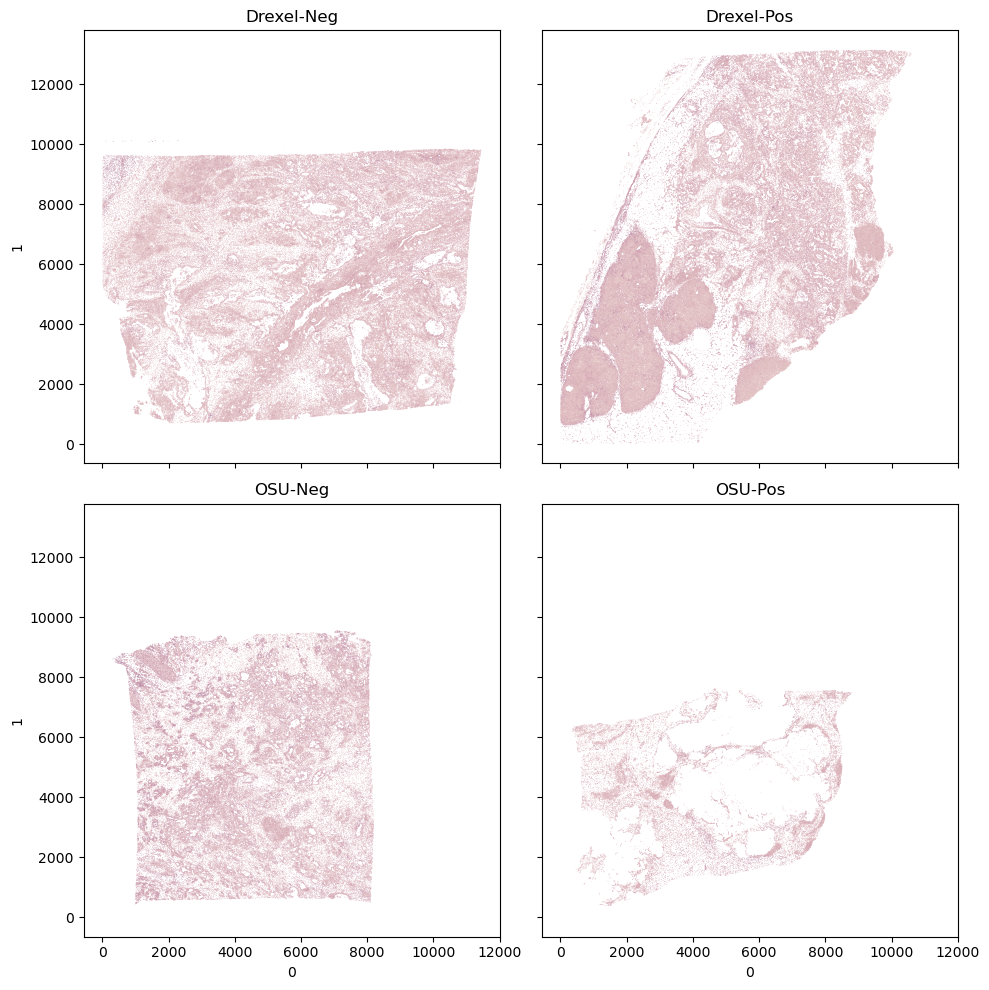

In [14]:

fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=True, sharey=True)

spatials = pd.DataFrame(normed_data.obsm['spatial'], index=normed_data.obs.index)
scores = pd.DataFrame(normed_data.obsm['score_ulm_hallmark_res0p5'], index=normed_data.obs.index)

for ax, (sample, sdf) in zip(axs.flatten(), normed_data.obs.groupby('sample')):
    
    ax.set_title(sample)
    sample_spatial = spatials.loc[sdf.index]
    score = scores.loc[sdf.index]
    
    sns.scatterplot(x = sample_spatial[0], y = sample_spatial[1], hue=score['TNFA_SIGNALING_VIA_NFKB'], ax=ax, s=0.1, legend=False)

fig.tight_layout()

In [123]:
results = []

for clust, cdf in normed_data.obs.groupby('leiden_res0p5'):
    cluster_ulm = score_ulm.loc[cdf.index]
    mask = cdf['HIV_POS']
    pos_ulm = cluster_ulm.loc[mask]
    neg_ulm = cluster_ulm.loc[~mask]
    delta = pos_ulm.mean(axis=0)-neg_ulm.mean(axis=0)
    stats, pvals = ranksums(pos_ulm, neg_ulm, alternative='two-sided', axis=0, nan_policy='omit', keepdims=False)
    for stat, pval, d, col in zip(stats.flatten(), pvals.flatten(), delta, pos_ulm.columns):
        results.append({'cluster': clust,
                        'target': col,
                        'stat': stat,
                        'pval': pval, 
                        'delta_mean': d})
        
res_df = pd.DataFrame(results)
res_df['pval_adj'] = false_discovery_control(res_df['pval'])
res_df


/tmp/ipykernel_374/1005472584.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, cdf in normed_data.obs.groupby('leiden_res0p5'):


,cluster,target,stat,pval,delta_mean,pval_adj
0,0,ADIPOGENESIS,-23.601294,3.737945e-123,-0.369950,9.768148e-123
1,0,ALLOGRAFT_REJECTION,-57.247032,0.000000e+00,-0.728565,0.000000e+00
2,0,ANDROGEN_RESPONSE,-37.009136,8.164416e-300,-0.663817,3.309899e-299
3,0,ANGIOGENESIS,-0.334826,7.377567e-01,-0.027363,7.497527e-01
4,0,APICAL_JUNCTION,-17.546957,6.275291e-69,-0.279975,1.329511e-68
...,...,...,...,...,...,...
745,14,UNFOLDED_PROTEIN_RESPONSE,10.844422,2.119723e-27,0.426761,3.613163e-27
746,14,UV_RESPONSE_DN,-18.260775,1.698625e-74,-0.483186,3.725055e-74
747,14,UV_RESPONSE_UP,12.956184,2.167663e-38,0.274377,4.064368e-38
748,14,WNT_BETA_CATENIN_SIGNALING,-11.417365,3.424601e-30,-0.244493,5.945487e-30


In [125]:
res_df[(res_df['pval_adj']<0.01)&(res_df['delta_mean'].abs()>1.5)]




,cluster,target,stat,pval,delta_mean,pval_adj
59,1,COAGULATION,-48.552737,0.000000e+00,-2.017025,0.000000e+00
60,1,COMPLEMENT,-47.527817,0.000000e+00,-1.888828,0.000000e+00
75,1,INTERFERON_ALPHA_RESPONSE,-50.680482,0.000000e+00,-2.153711,0.000000e+00
76,1,INTERFERON_GAMMA_RESPONSE,-52.292078,0.000000e+00,-2.477712,0.000000e+00
81,1,MYC_TARGETS_V1,32.699682,1.578099e-234,1.848200,5.582897e-234
95,1,UNFOLDED_PROTEIN_RESPONSE,28.271829,7.674528e-176,1.558434,2.349345e-175
118,2,GLYCOLYSIS,-85.295989,0.000000e+00,-1.715448,0.000000e+00
121,2,HYPOXIA,-79.937060,0.000000e+00,-2.274137,0.000000e+00
130,2,MTORC1_SIGNALING,-88.650562,0.000000e+00,-2.236768,0.000000e+00
131,2,MYC_TARGETS_V1,-106.127142,0.000000e+00,-2.846370,0.000000e+00


<Axes: xlabel='val', ylabel='Count'>

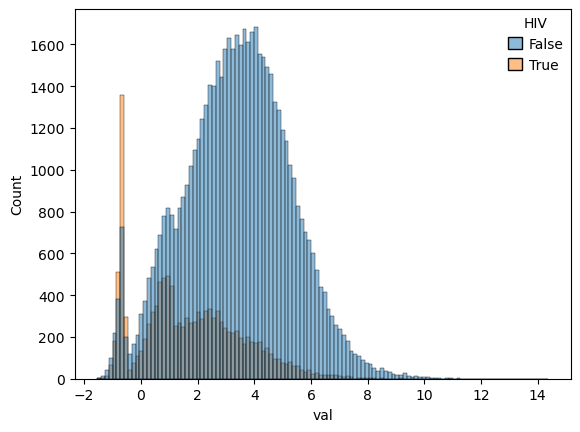

In [129]:
cdf = normed_data.obs.query('leiden_res0p5=="2"')
wanted = pd.DataFrame({'val': score_ulm.loc[cdf.index, 'UNFOLDED_PROTEIN_RESPONSE'],
                        'HIV': cdf['HIV_POS']})
sns.histplot(data=wanted, x='val', hue = 'HIV')

In [64]:
mask = cdf['HIV_POS']
mask.mean()

np.float64(0.5707948625367514)

In [69]:
results = []


(50,)

In [71]:
pvals < 0.001

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [40]:
score = sc.get.obs_df(adata=normed_data, key="score_ulm")
score

TypeError: obs_df() got an unexpected keyword argument 'key'

In [38]:
score.X.shape

(992465, 50)

In [36]:
cells = score.obs['leiden_res0p5'] == 0

wdata = 

AttributeError: 'AxisArrays' object has no attribute 'index'

In [34]:
for cluster, cdf in score.obs.groupby('leiden_res0p5'):
    print(cluster)
    
    sc.tl.rank_genes_groups(cdf, )
    
    
    
    pos = score.obsm.loc[mask.index, 'score_ulm'][mask]
    neg = score.obsm.loc[mask.index, 'score_ulm'][~mask]
    
    print(pos.shape)
    print(neg.shape)
    
    
    
    
    
    
    

/tmp/ipykernel_374/3052618529.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, cdf in score.obs.groupby('leiden_res0p5'):


0


AttributeError: 'AxisArrays' object has no attribute 'loc'

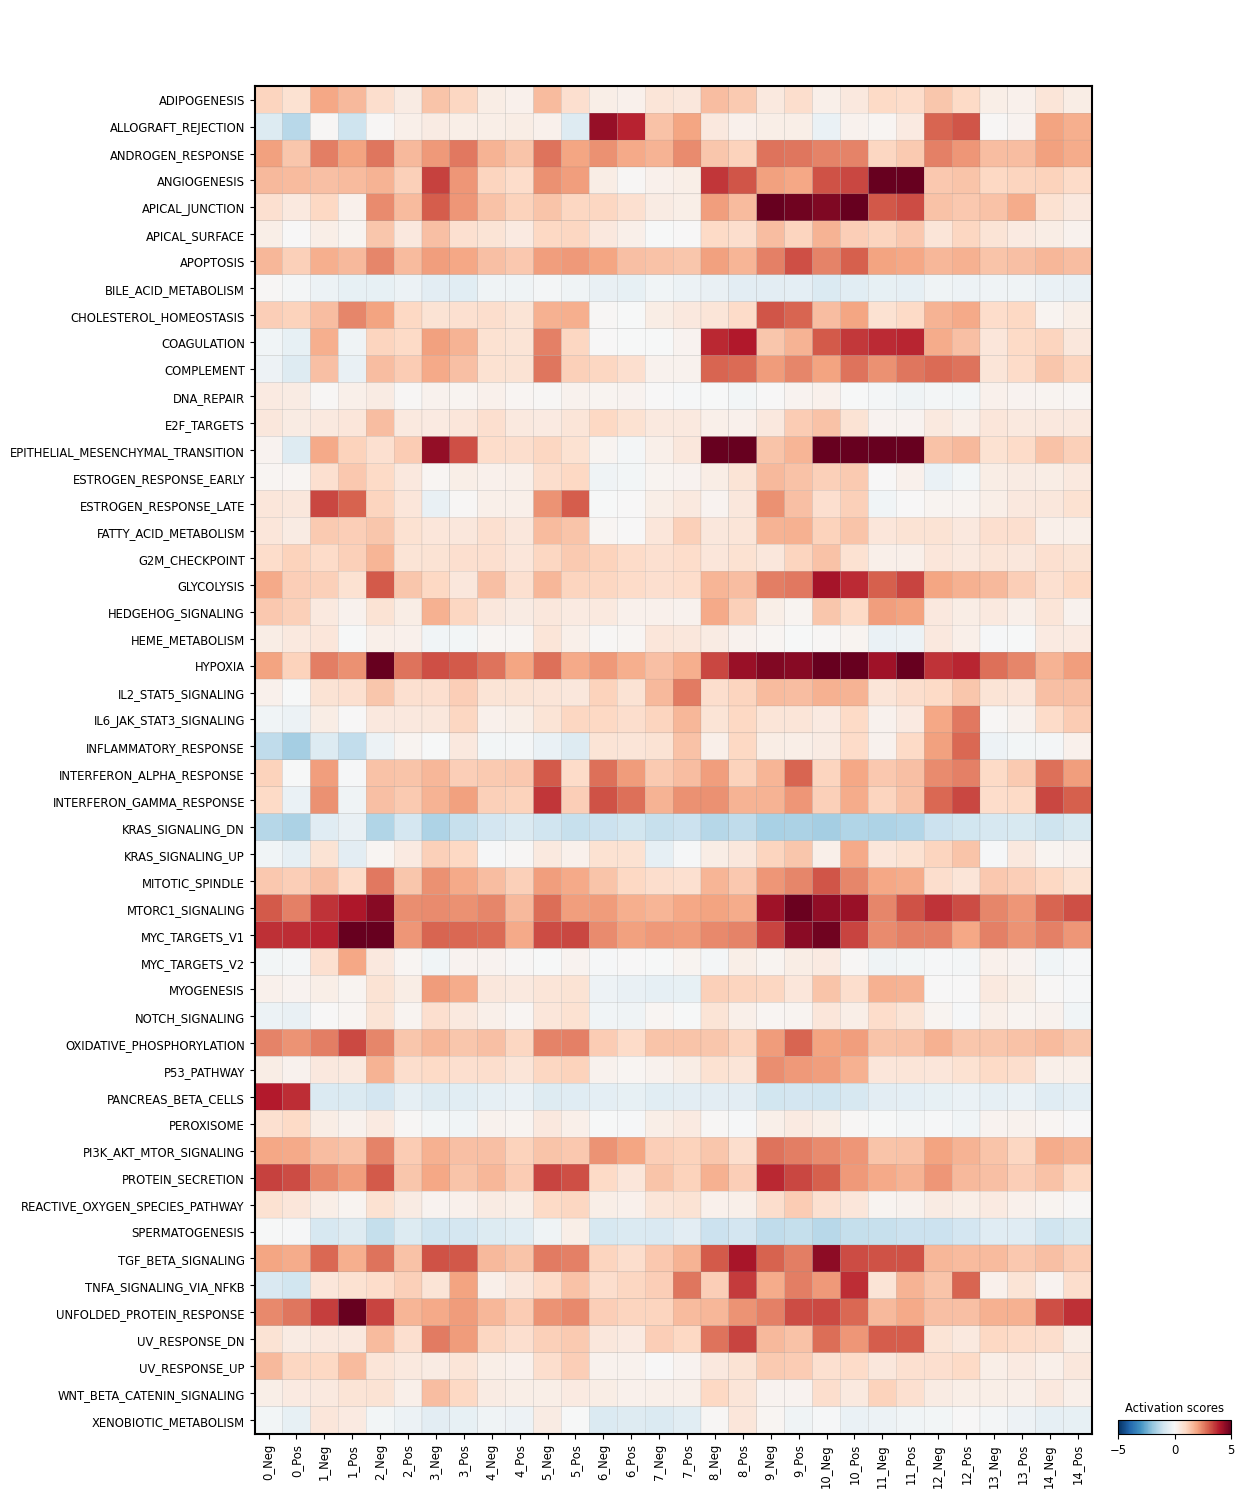

In [33]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby=["leiden_res0p5", 'sample_type'],
    dendrogram=False,
    standard_scale=None,
    colorbar_title="Activation scores",
    cmap="RdBu_r",
    swap_axes=True,
    vmin=-5, vmax=5, vcenter=0
)

In [15]:
normed_data.obs['sample']

0          Drexel-Neg
1          Drexel-Neg
2          Drexel-Neg
3          Drexel-Neg
4          Drexel-Neg
              ...    
74281-3       OSU-Pos
74298-3       OSU-Pos
74313-3       OSU-Pos
74319-3       OSU-Pos
74322-3       OSU-Pos
Name: sample, Length: 992465, dtype: category
Categories (4, object): ['Drexel-Neg', 'Drexel-Pos', 'OSU-Neg', 'OSU-Pos']

In [14]:
pd.crosstab(normed_data.obs['leiden_res0p5'], normed_data.obs['sample'])

sample,Drexel-Neg,Drexel-Pos,OSU-Neg,OSU-Pos
leiden_res0p5,,,,
0,7492,11051,829,15
1,1220,90000,94,14
2,54873,11125,2668,1665
3,21987,24369,13524,7366
4,1429,710,498,252
5,24222,37304,1358,110
6,26629,17602,9899,16437
7,2728,1522,821,392
8,16925,25006,4511,15923
